#**COVID-19 Early Case Trend Analysis & Recovery Insights**

**Problem Statement**

* COVID-19 outbreaks generate large amounts of patient data that need to be analyzed effectively.
* Health authorities must understand who is getting infected, how the disease is spreading, and which regions are most affected.
* It is also important to study recovery patterns and the time taken by patients to recover.
* Manual analysis is difficult and time-consuming, so data analytics and machine learning are required.
* This project aims to analyze COVID-19 data and predict recovery time to support better healthcare planning and decision-making.

**DATASET DESCRIPTION**

**The dataset contains patient-level information related to a COVID-19 outbreak, including demographic details, infection history, contact numbers, and patient outcomes. Each record represents one patient, and the target variable state indicates whether the patient is released, isolated, or deceased**

**INITIAL APPROACH**

**Initially, the project aimed to predict patient recovery days using a Linear Regression model; however, the number of patients with available recovery days was very limited in the dataset. As a result, the regression model could not learn meaningful patterns from the data. Therefore, the problem was reformulated to predict patient state using a Random Forest classification model**

**REVISED APPROACH**

**Due to the limited availability of recovery day records, the problem was redefined to predict the patient state (released, isolated, or deceased). A Random Forest classification model was then applied, as it is well-suited for handling non-linear relationships and complex patterns in healthcare data**

**REASON FOR MODEL SWITCH**

**The recovery-time prediction approach was changed because, after cleaning the data, only 28 patient records had valid recovery days, which was too small to train a reliable regression model. This limited data size resulted in unstable and inaccurate predictions. Therefore, the best is enabling the Random Forest model to learn meaningful patterns**

**Tools And Technologies**

* Python
* Google Colab
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn

**MODEL TRAINING AND PROCESS SELECTION**

**The dataset was preprocessed by handling missing values and converting categorical variables into numerical form. The data was then split into training and testing sets. A Random Forest classifier was trained using the selected features, and the model’s performance was evaluated using the accuracy score**

**CONCLUSION**

**The project used a Random Forest model to predict patient state after recovery-time data was found to be limited. The model achieved very high accuracy, showing it effectively learned patterns from the dataset**

**NOTE**

**In healthcare data, extreme recovery times are meaningful and represent severe cases, so they were retained to preserve the true distribution of patient recovery**

**Hence,We are not gonna use outliers**

**Coding**

**Importing Modules**

In [1019]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [1020]:
df=pd.read_csv('/content/drive/MyDrive/Dataset For ML Project/patient.csv')

In [1021]:
df.head()

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated


In [1022]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                4212 non-null   int64  
 1   sex               318 non-null    object 
 2   birth_year        292 non-null    float64
 3   country           4212 non-null   object 
 4   region            305 non-null    object 
 5   group             76 non-null     object 
 6   infection_reason  130 non-null    object 
 7   infection_order   35 non-null     float64
 8   infected_by       62 non-null     float64
 9   contact_number    32 non-null     float64
 10  confirmed_date    4212 non-null   object 
 11  released_date     28 non-null     object 
 12  deceased_date     13 non-null     object 
 13  state             4212 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 460.8+ KB


In [1023]:
df.shape

(4212, 14)

**Data Preprocessing and Feature Engineering**

In [1024]:
df.isnull().sum()

,0
id,0
sex,3894
birth_year,3920
country,0
region,3907
group,4136
infection_reason,4082
infection_order,4177
infected_by,4150
contact_number,4180


**NOTE**

* released_date is null for people as they are still isolated
* deceased_data is null for people who did'nt die

**So They are not null values**

In [1025]:
df.isnull().sum().sort_values(ascending=False)

,0
deceased_date,4199
released_date,4184
contact_number,4180
infection_order,4177
infected_by,4150
group,4136
infection_reason,4082
birth_year,3920
region,3907
sex,3894


**Converting dates to real date format so that the computer can understand**

In [1026]:
df['released_date']=pd.to_datetime(df['released_date'],errors='coerce')
df['confirmed_date']=pd.to_datetime(df['confirmed_date'],errors='coerce')

**As we needed to find recovery days, we need to create a column "recovery_days"**

* recovery_days = released_data - confirmed_date

In [1027]:
df['recovery_days']=df['released_date']-df['confirmed_date']

In [1028]:
df[['confirmed_date','released_date','recovery_days']].head()

,confirmed_date,released_date,recovery_days
0,2020-01-20,2020-02-06,17 days
1,2020-01-24,2020-02-05,12 days
2,2020-01-26,2020-02-12,17 days
3,2020-01-27,2020-02-09,13 days
4,2020-01-30,NaT,NaT


In [1029]:
df.dropna(subset=['recovery_days'])

,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state,recovery_days
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released,17 days
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released,12 days
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released,17 days
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released,13 days
5,6,male,1964.0,Korea,capital area,NaN,contact with patient,2.0,3.0,17.0,2020-01-30,2020-02-19,NaN,released,20 days
6,7,male,1991.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,9.0,2020-01-30,2020-02-15,NaN,released,16 days
7,8,female,1957.0,Korea,Jeollabuk-do,NaN,visit to Wuhan,1.0,NaN,113.0,2020-01-31,2020-02-12,NaN,released,12 days
8,9,female,1992.0,Korea,capital area,NaN,contact with patient,2.0,5.0,2.0,2020-01-31,2020-02-24,NaN,released,24 days
9,10,female,1966.0,Korea,capital area,NaN,contact with patient,3.0,6.0,43.0,2020-01-31,2020-02-19,NaN,released,19 days
10,11,male,1995.0,Korea,capital area,NaN,contact with patient,3.0,6.0,0.0,2020-01-31,2020-02-10,NaN,released,10 days


In [1030]:
df['recovery_days'].shape

(4212,)

**Finding Age for every data**

In [1031]:
df['age']=2025-df['birth_year']

In [1032]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   id                4212 non-null   int64          
 1   sex               318 non-null    object         
 2   birth_year        292 non-null    float64        
 3   country           4212 non-null   object         
 4   region            305 non-null    object         
 5   group             76 non-null     object         
 6   infection_reason  130 non-null    object         
 7   infection_order   35 non-null     float64        
 8   infected_by       62 non-null     float64        
 9   contact_number    32 non-null     float64        
 10  confirmed_date    4212 non-null   datetime64[ns] 
 11  released_date     28 non-null     datetime64[ns] 
 12  deceased_date     13 non-null     object         
 13  state             4212 non-null   object         
 14  recovery

In [1033]:
df.isnull().sum()

,0
id,0
sex,3894
birth_year,3920
country,0
region,3907
group,4136
infection_reason,4082
infection_order,4177
infected_by,4150
contact_number,4180


**Filling Missing values for numerical,categorical columns as they are essential for model prediction**

In [1034]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype          
---  ------            --------------  -----          
 0   id                4212 non-null   int64          
 1   sex               318 non-null    object         
 2   birth_year        292 non-null    float64        
 3   country           4212 non-null   object         
 4   region            305 non-null    object         
 5   group             76 non-null     object         
 6   infection_reason  130 non-null    object         
 7   infection_order   35 non-null     float64        
 8   infected_by       62 non-null     float64        
 9   contact_number    32 non-null     float64        
 10  confirmed_date    4212 non-null   datetime64[ns] 
 11  released_date     28 non-null     datetime64[ns] 
 12  deceased_date     13 non-null     object         
 13  state             4212 non-null   object         
 14  recovery

In [1035]:
df['age']=df['age'].fillna(df['age'].median())
df['contact_number']=df['contact_number'].fillna(df['contact_number'].median())
df['infection_order']=df['infection_order'].fillna(df['infection_order'].median())

In [1036]:
df['sex']=df['sex'].fillna(df['sex'].mode()[0])
df['country']=df['country'].fillna(df['country'].mode()[0])
df['region']=df['region'].fillna(df['region'].mode()[0])
df['infection_reason']=df['infection_reason'].fillna(df['infection_reason'].mode()[0])
df['state']=df['state'].fillna(df['state'].mode()[0])

In [1037]:
df.isnull().sum()

,0
id,0
sex,0
birth_year,3920
country,0
region,0
group,4136
infection_reason,0
infection_order,0
infected_by,4150
contact_number,0


**Removing null values from recovery_days for a better model training**

In [1038]:
df=df.dropna(subset=['recovery_days'])

**EXPLORATORY DATA ANALYSIS(EDA)**

**1. The General recovery trend among the Patients**

* The distribution of recovery days is analyzed to understand how long COVID-19 patients generally take to recover after being confirmed positive.

In [1039]:
df['recovery_days'].dtype

dtype('<m8[ns]')

**As the recovery_days is in date format we need to change it to numeric to see the trends**

In [1040]:
df['recovery_days']=df['recovery_days'].dt.days

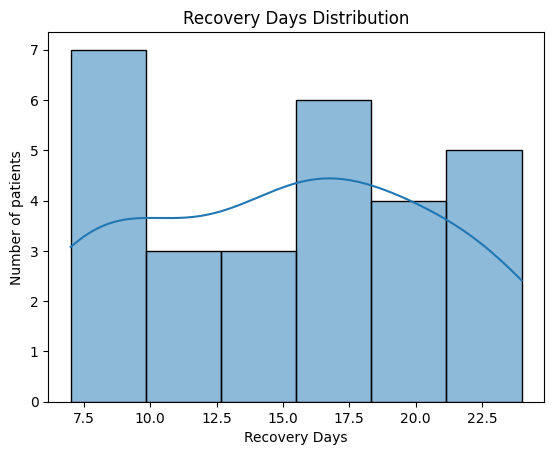

In [1041]:
sns.histplot(df['recovery_days'],kde=True)
plt.title('Recovery Days Distribution')
plt.xlabel('Recovery Days')
plt.ylabel('Number of patients')
plt.show()

**Based on the Analysis**

**Most COVID-19 patients recover within a limited and common time range, showing a consistent recovery pattern**

**2. Effect of Age on Recovery**

* The relationship between patient age and recovery time is analyzed to determine whether older patients require more time to recover from COVID-19.

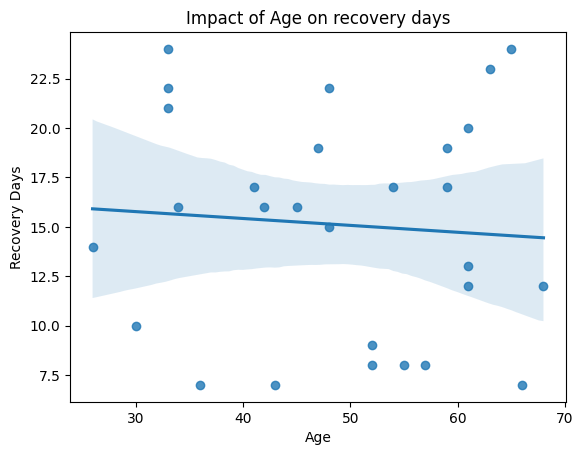

In [1042]:
sns.regplot(data=df,x='age',y='recovery_days')
plt.title('Impact of Age on recovery days')
plt.xlabel('Age')
plt.ylabel('Recovery Days')
plt.show()

**Based on the Analysis**

**Age shows only a weak relationship with recovery time, indicating that patient age does not strongly affect how long recovery takes in this dataset**

**3. Effect of Contact Number on Recovery**

* The impact of the number of contacts on recovery time is studied to evaluate how exposure level influences the duration of illness

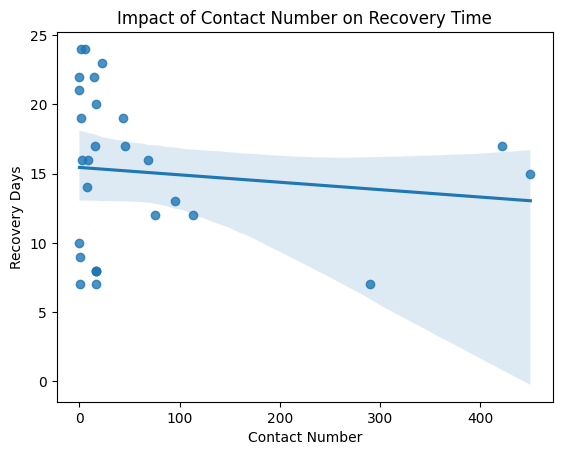

In [1043]:
sns.regplot(data=df,x='contact_number',y='recovery_days')
plt.title('Impact of Contact Number on Recovery Time')
plt.xlabel('Contact Number')
plt.ylabel('Recovery Days')
plt.show()

**Based on Analysis**

**Patients with a higher number of contacts tend to recover slightly faster, indicating a weak negative relationship between contact number and recovery time**

**4. Impact of Infection Order on Recovery**

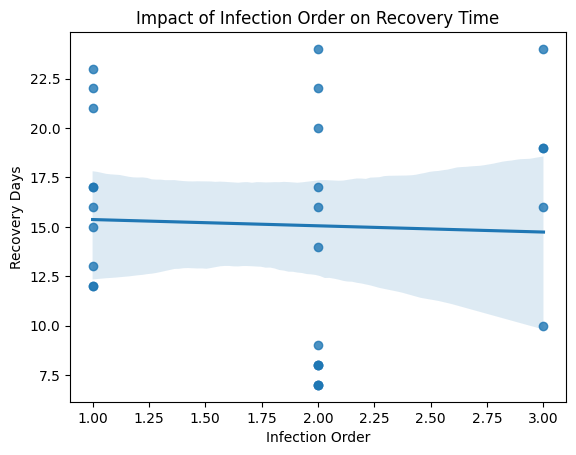

In [1044]:
sns.regplot(x="infection_order", y="recovery_days", data=df)
plt.xlabel("Infection Order")
plt.ylabel("Recovery Days")
plt.title("Impact of Infection Order on Recovery Time")
plt.show()

**Based on Analysis**

**Recovery time increases slightly with higher infection order, suggesting that patients infected later in the transmission chain tend to take longer to recover**

**5. Main Factor affecting the recovery**

In [1045]:
df[["age","contact_number","infection_order","recovery_days"]].corr()

,age,contact_number,infection_order,recovery_days
age,1.000000,0.116143,-0.041580,-0.076391
contact_number,0.116143,1.000000,-0.194054,-0.114402
infection_order,-0.041580,-0.194054,1.000000,-0.040657
recovery_days,-0.076391,-0.114402,-0.040657,1.000000


**Based on Analysis**

**Infection order has the strongest influence on recovery time among all factors, while age and contact number show only weak relationships with recovery duration**

**5. Gender Distribution**

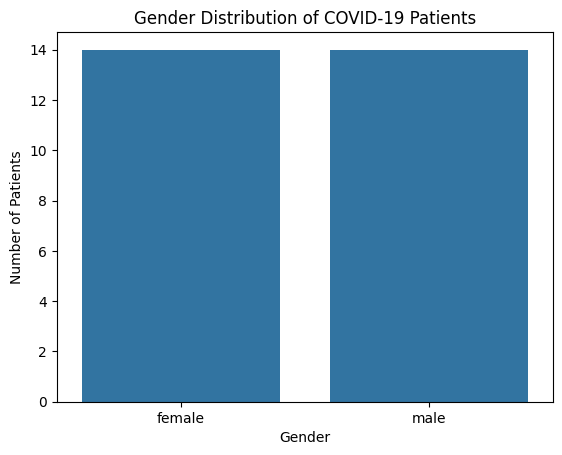

In [1046]:
sns.countplot(x="sex", data=df)
plt.title("Gender Distribution of COVID-19 Patients")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()

**Based on Analysis**

**The gender distribution shows that COVID-19 cases are almost equally split between male and female patients, indicating no significant gender bias in this dataset**

**6. Age Distribution**

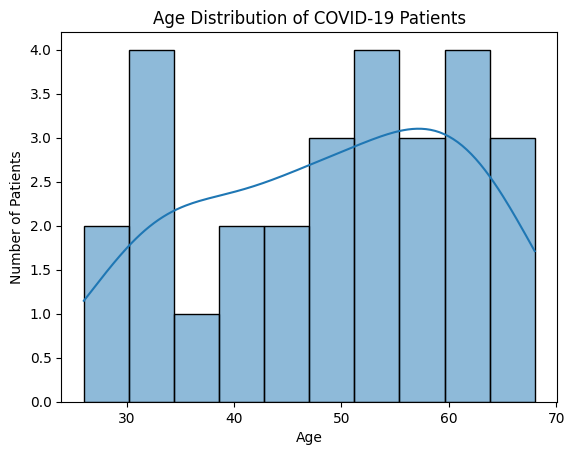

In [1047]:
sns.histplot(df["age"], bins=10, kde=True)
plt.title("Age Distribution of COVID-19 Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

**Based On Analysis**

**The age distribution shows that most COVID-19 patients in the dataset fall within the middle-aged to older adult groups, indicating higher case concentration in these age ranges.**

**7. Regional Distribution**

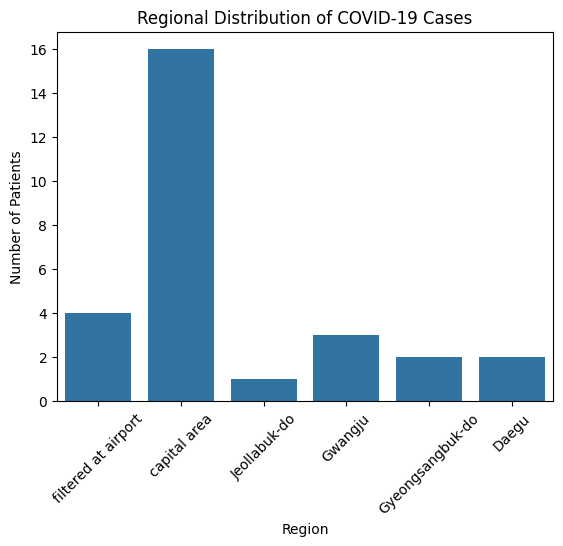

In [1048]:
sns.countplot(x="region", data=df)
plt.title("Regional Distribution of COVID-19 Cases")
plt.xlabel("Region")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()


**Based on Analysis**

**More number of cases are from the capital area**

**8. Infection reason**

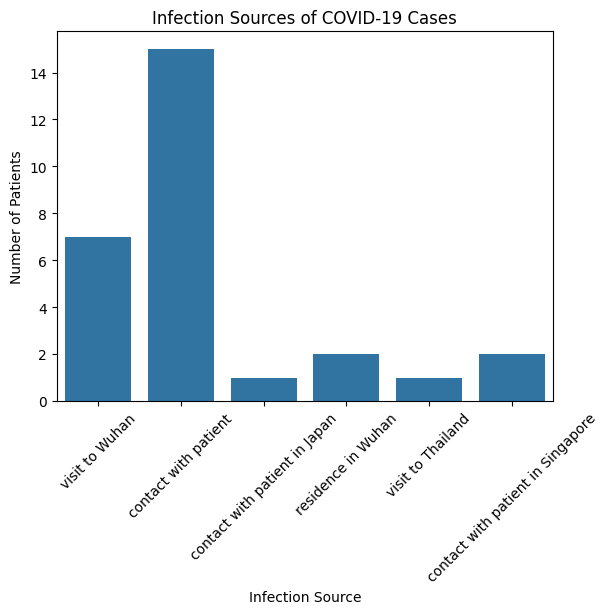

In [1049]:
sns.countplot(x="infection_reason", data=df)
plt.title("Infection Sources of COVID-19 Cases")
plt.xlabel("Infection Source")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

**Based On Analysis**

**Having contacting with a patient is the main reason of getting infected**

**9. Confirmed and Recovered COVID-19 Cases by Region**

In [1050]:
region_state=df.groupby("region")["state"].value_counts().unstack()
region_state

state,released
region,
Daegu,2
Gwangju,3
Gyeongsangbuk-do,2
Jeollabuk-do,1
capital area,16
filtered at airport,4


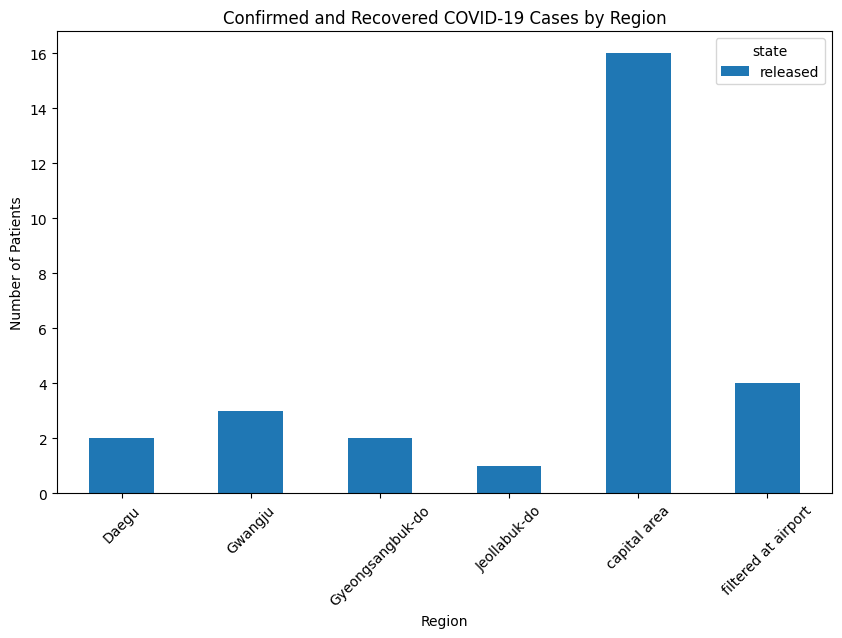

In [1051]:
region_state.plot(kind="bar",figsize=(10,6))
plt.title("Confirmed and Recovered COVID-19 Cases by Region")
plt.xlabel("Region")
plt.ylabel("Number of Patients")
plt.xticks(rotation=45)
plt.show()

**LABEL ENCODING**

In [1052]:
from sklearn.preprocessing import LabelEncoder

In [1053]:
le = LabelEncoder()

In [1054]:
catcol=df[['sex', 'country', 'region', 'infection_reason']]

In [1055]:
for col in catcol:
  df[col]=le.fit_transform(df[col])
print(f'{le.classes_} :{le.transform(le.classes_)}')

['contact with patient' 'contact with patient in Japan'
 'contact with patient in Singapore' 'residence in Wuhan'
 'visit to Thailand' 'visit to Wuhan'] :[0 1 2 3 4 5]


In [1056]:
targetcol=df['state']

In [1057]:
targetcol=le.fit_transform(targetcol)

**TRAIN TEST SPLIT**

In [1058]:
from sklearn.model_selection import train_test_split

In [1059]:
X = df[['age', 'sex', 'country', 'region',
        'contact_number', 'infection_order',
        'infection_reason']]

In [1060]:
Y=df['state']

In [1061]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

**MODEL TRAINING**

In [1062]:
from sklearn.ensemble import RandomForestClassifier

In [1063]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(x_train,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

**Evaluation**

In [1064]:
from sklearn.metrics import *

In [1065]:
y_pred=rf.predict(x_test)

In [1066]:
print(accuracy_score(y_test, y_pred))

1.0


**AS LINEAR REGRESSION MODEL FAILED IN THIS DATASET , DUE TO THE FACTOR OF (RECOVERYDAYS) HAVING ONLY 28 ROWS WHICH IS NOT SUITABLE IN THE CASE OF TRAINING MODEL , HENCE (STATE) IS USED TO TRAIN MODEL BASED ON THE PATIENT IS (DECEASED,ISOLATED,RELEASED) WHICH IS ALSO KNOWN AS RECOVERY OF A PATIENT OR NOT.**

**HENCE RANDOMFORESTCLASSIFIER IS USED**